# Aula 13: Desafio

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from graph_tool.all import *

In [2]:
sns.set()

In [3]:
g = load_graph('petfriends.gt')

In [4]:
satisfacao = g.vp['satisfacao']
satisfacao_int = []

for i in satisfacao:
    if i == 'muito baixa':
        satisfacao_int.append(0.0)
    elif i == 'baixa':
        satisfacao_int.append(0.25)
    elif i == 'média':
        satisfacao_int.append(0.5)
    elif i == 'alta':
        satisfacao_int.append(0.75)
    elif i == 'muito alta':
        satisfacao_int.append(1.0)

df = pd.DataFrame({
    'desempenho': g.vp['desempenho'],
    'satisfacao': satisfacao_int,
})

df

,desempenho,satisfacao
0,4.79,0.25
1,6.13,0.50
2,4.96,0.75
3,6.38,0.00
4,4.58,0.25
...,...,...
371,3.18,0.25
372,4.41,0.50
373,3.89,0.50
374,2.91,0.25


In [6]:
df['satisfacao'].value_counts()

satisfacao
0.50    128
0.25     87
0.75     72
0.00     54
1.00     35
Name: count, dtype: int64

In [7]:
dep = df['satisfacao']
ind = df['desempenho']
ind = sm.add_constant(ind)
model = sm.Logit(dep, ind)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.672915
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             satisfacao   No. Observations:                  376
Model:                          Logit   Df Residuals:                      374
Method:                           MLE   Df Model:                            1
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.01887
Time:                        17:06:31   Log-Likelihood:                -253.02
converged:                       True   LL-Null:                       -257.88
Covariance Type:            nonrobust   LLR p-value:                  0.001812
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7406      0.250     -2.965      0.003      -1.230      -0.251
desempenho     0.1297      0.049      2.650      0.008       0.034       0.226
==============================================================================
"""

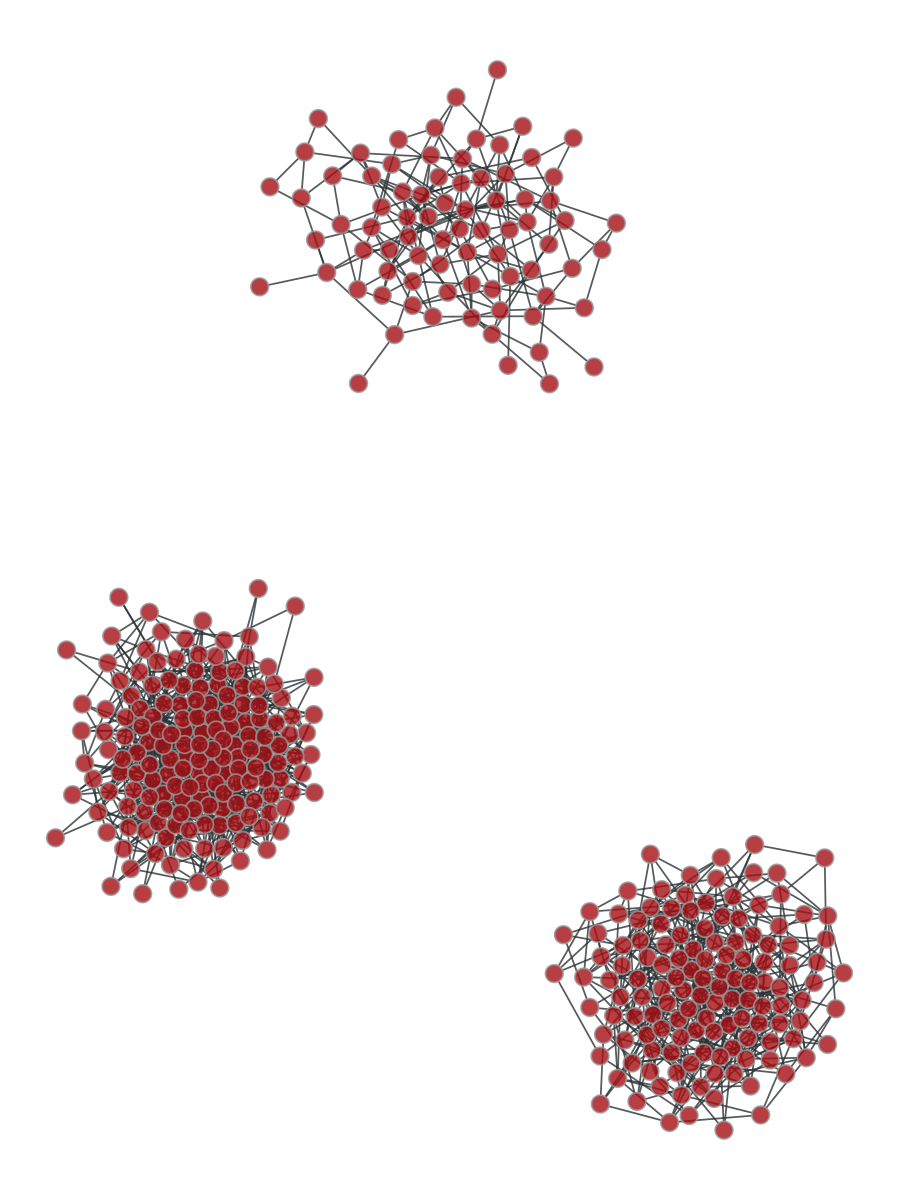

In [9]:
graph_draw(g);

2.6

Formalmente, ilhas são componentes conectados de um grafo, isto é, um subgrafo. Visualizando a rede, o Diretor de Pessoas parece certo em relação a existência delas.

In [10]:
c, h = label_components(g)

df['ilha'] = c.a

dummies = pd.get_dummies(df['ilha'], dtype=int,drop_first=True)

for i in dummies:
    df[f'ilha-{i}'] = dummies[i]
    
df

,desempenho,satisfacao,ilha,ilha-1,ilha-2
0,4.79,0.25,0,0,0
1,6.13,0.50,0,0,0
2,4.96,0.75,0,0,0
3,6.38,0.00,0,0,0
4,4.58,0.25,0,0,0
...,...,...,...,...,...
371,3.18,0.25,2,0,1
372,4.41,0.50,2,0,1
373,3.89,0.50,2,0,1
374,2.91,0.25,2,0,1


In [11]:
dep = df['satisfacao']
ind = df[['desempenho','ilha-1','ilha-2']]
ind = sm.add_constant(ind)
model = sm.Logit(dep, ind)
result = model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.603634
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             satisfacao   No. Observations:                  376
Model:                          Logit   Df Residuals:                      372
Method:                           MLE   Df Model:                            3
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.1199
Time:                        17:06:31   Log-Likelihood:                -226.97
converged:                       True   LL-Null:                       -257.88
Covariance Type:            nonrobust   LLR p-value:                 2.390e-13
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0176      0.326      0.054      0.957      -0.622       0.657
desempenho    -0.0115      0.057     -0.202      0.840      -0.123       0.100
ilha-1         1.0703      0.319      3.353      0.001       0.445       1.696
ilha-2        -0.7468      0.252     -2.969      0.003      -1.240      -0.254
==============================================================================
"""

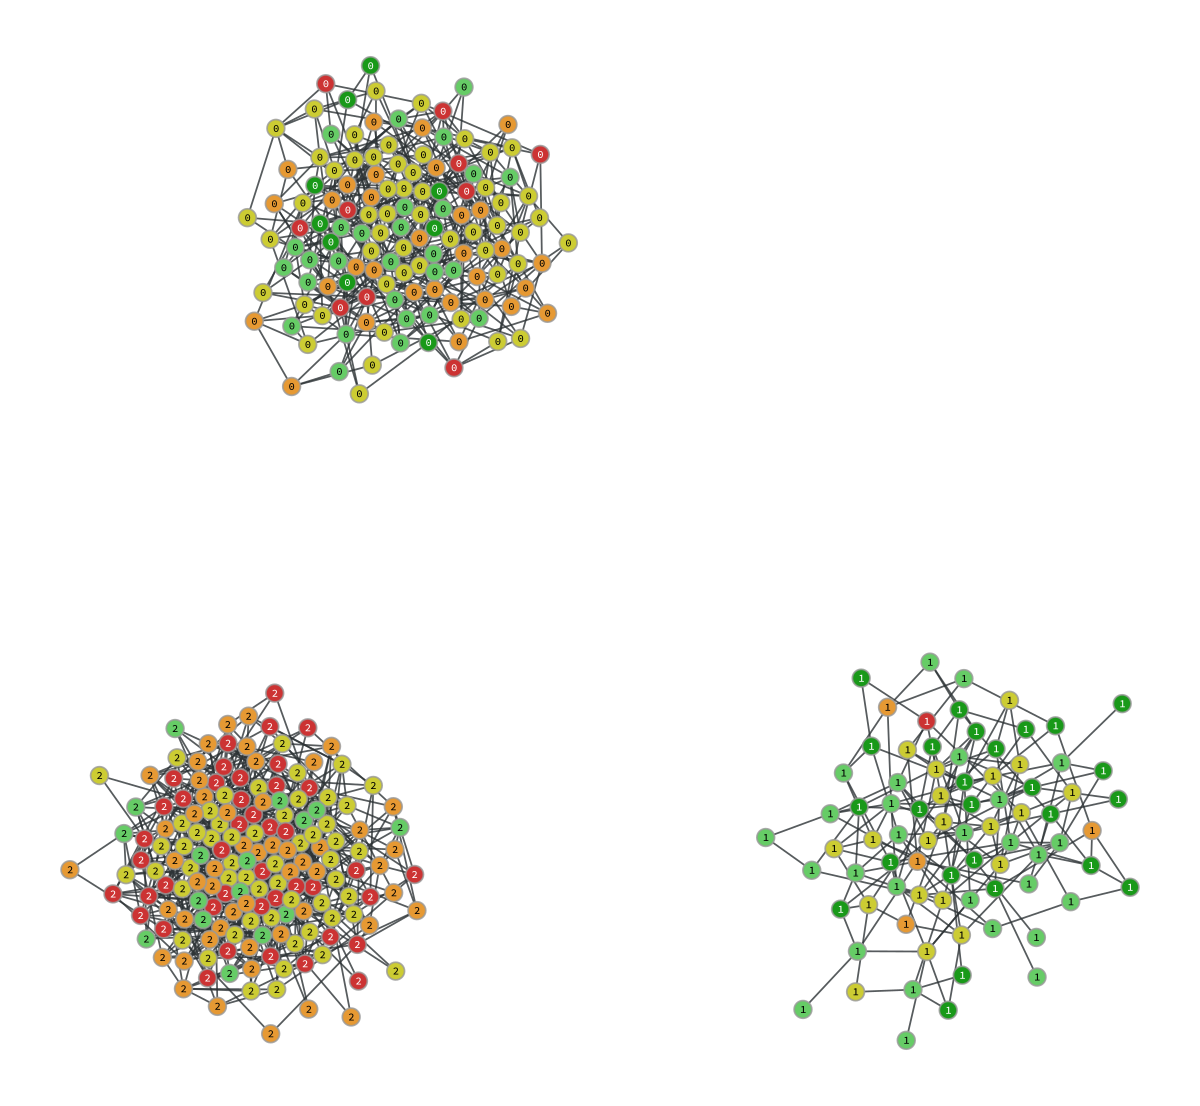

<VertexPropertyMap object with value type 'vector<double>', for Graph 0xffff9749f8c0, at 0xffff400dab30>

In [12]:
cores_satisfacao = {
    "muito baixa": [0.8, 0.2, 0.2, 1.0],
    "baixa":       [0.9, 0.6, 0.2, 1.0],
    "média":       [0.8, 0.8, 0.2, 1.0],
    "alta":        [0.4, 0.8, 0.4, 1.0],
    "muito alta":  [0.1, 0.6, 0.1, 1.0]
}

v_color = g.new_vp("vector<double>")

for v in g.vertices():
    nivel = g.vp['satisfacao'][v]
    v_color[v] = cores_satisfacao.get(nivel, [0.7, 0.7, 0.7, 1.0])

graph_draw(g, vertex_text=c, vertex_fill_color=v_color)
